Статистика скалярного поля: {'Среднее': np.float64(0.18260762972068648), 'СКО': np.float64(0.6811552364511895), 'Мин': np.float64(-1.120443060738112), 'Макс': np.float64(1.1752373919659806)}


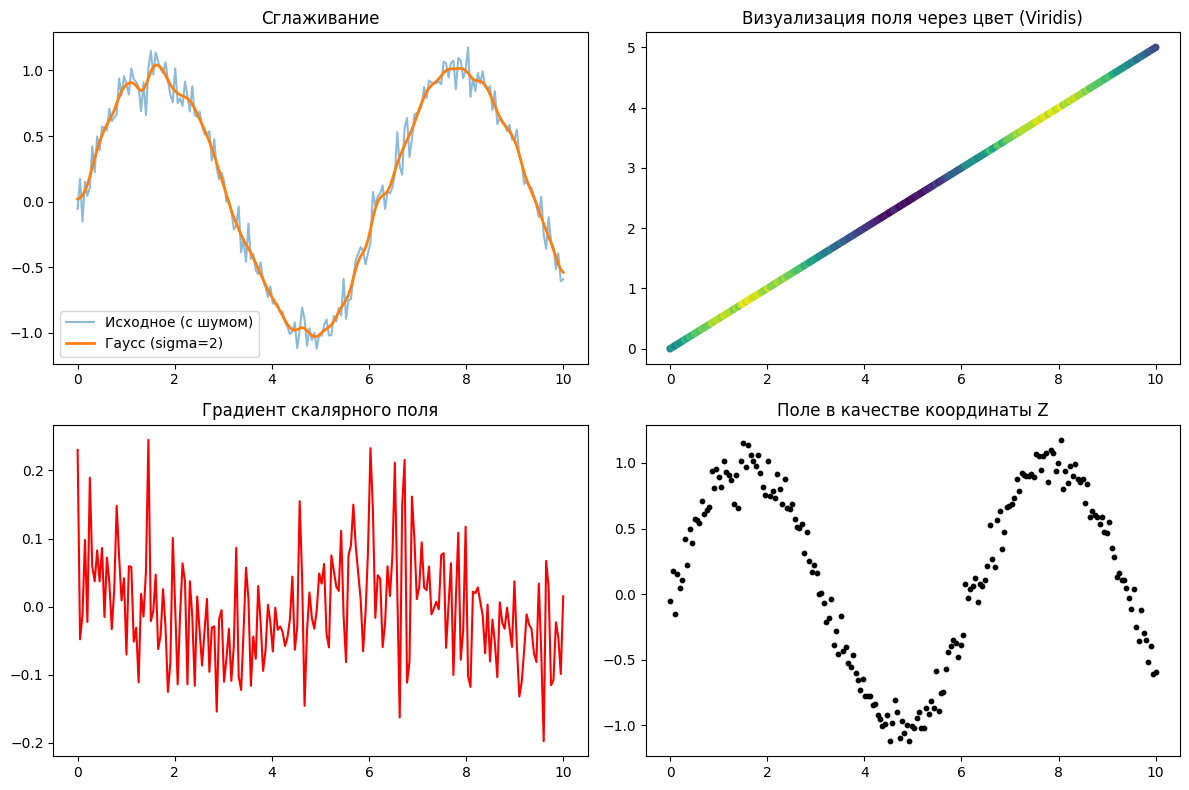

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

# Генерируем данные: 200 точек вдоль линии с небольшим разбросом
N = 200
x_coords = np.linspace(0, 10, N)
y_coords = np.zeros(N)
z_coords = x_coords * 0.5  # Наклонная плоскость
xyz = np.column_stack((x_coords, y_coords, z_coords))

# Исходное скалярное поле: синусоида + случайный шум
scalar_field = np.sin(x_coords) + np.random.normal(0, 0.1, N)

# Задания 1-3: Арифметика
sf_const = np.full(N, 10.0)    # Задание 1
sf_mult = scalar_field * 2      # Задание 2
sf_add = scalar_field + 5       # Задание 3

# Задание 4: Гауссов фильтр
smoothed_gauss = gaussian_filter1d(scalar_field, sigma=2)

# Задание 5: Градиент
gradient = np.gradient(scalar_field)

# Задание 6: Скользящее среднее
def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')
smoothed_ma = moving_average(scalar_field, window_size=5)

# Задание 8: Статистика
stats = {
    "Среднее": scalar_field.mean(),
    "СКО": scalar_field.std(),
    "Мин": scalar_field.min(),
    "Макс": scalar_field.max()
}
print("Статистика скалярного поля:", stats)

# Задание 9: Нормализация [0, 1]
normed = (scalar_field - scalar_field.min()) / (scalar_field.max() - scalar_field.min())

# Задание 7: Цвета
colors = plt.cm.viridis(normed)[:, :3]

# Задание 10: Интерполяция пропусков
sf_with_nan = scalar_field.copy()
sf_with_nan[20:40] = np.nan # Искусственный пропуск

def interpolate_nan(data):
    nans = np.isnan(data)
    x = np.arange(len(data))
    f = interp1d(x[~nans], data[~nans], bounds_error=False, fill_value="extrapolate")
    return f(x)

filled_scalar = interpolate_nan(sf_with_nan)

# Задание 11: Фильтрация
mask = (scalar_field >= 0.5) & (scalar_field <= 1.5)
filtered_points = xyz[mask]

# Визуализация (Задание 12 и сравнение)
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_coords, scalar_field, label="Исходное (с шумом)", alpha=0.5)
plt.plot(x_coords, smoothed_gauss, label="Гаусс (sigma=2)", linewidth=2)
plt.legend()
plt.title("Сглаживание")

plt.subplot(2, 2, 2)
plt.scatter(xyz[:, 0], xyz[:, 2], c=colors, s=20)
plt.title("Визуализация поля через цвет (Viridis)")

plt.subplot(2, 2, 3)
plt.plot(x_coords, gradient, color='red')
plt.title("Градиент скалярного поля")

plt.subplot(2, 2, 4)
# Задание 12: Поле как координата Z
plt.scatter(xyz[:, 0], scalar_field, c='black', s=10)
plt.title("Поле в качестве координаты Z")

plt.tight_layout()
plt.savefig("scalar_results.png")
plt.show()

# Задание 13: Удаление
scalar_field = None